In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

### Data Download
`Top-10K-TMDB-movies.csv` from HuggingFace. 

In [23]:
import os 
os.chdir('../')

In [24]:
from cinevec.utils.file_utils import load_config_file

In [27]:
config = load_config_file()

[2026-07-07 14:56:38,952: INFO: file_utils: Loaded YAML file from config/config.yaml]


In [30]:
raw_file_url = config.data_url
df = pd.read_csv(raw_file_url)

In [5]:
df.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811


In [6]:
df.dtypes

id                     int64
title                    str
genre                    str
original_language        str
overview                 str
popularity           float64
release_date             str
vote_average         float64
vote_count             int64
dtype: object

### Data Cleaning 
* Missing values will be removed 
* Besides original ratings, we also use a Bayesian weighted rating system that accounts for the number of votes 
* Movie genres will be stored into a vector 

In [7]:
df.isnull().sum()

id                    0
title                 0
genre                 3
original_language     0
overview             13
popularity            0
release_date          0
vote_average          0
vote_count            0
dtype: int64

In [8]:
df = df.dropna(subset=['genre', 'overview'])
df.isnull().sum()

id                   0
title                0
genre                0
original_language    0
overview             0
popularity           0
release_date         0
vote_average         0
vote_count           0
dtype: int64

We will now check distribution of average ratings and Bayesian Average rating. For a movie $i$, Bayesian Average weighted rating $wr_i$ is defined as

$$wr_i = \frac{c_i}{c_i + M} r_i + \frac{M}{c_i + M} \bar{C}$$

with 

* $r_i$ the original rating of movie $i$
* $c_i$ the vote counts of movie $i$ 
* $C$ is the average rating across all movies
* $M$ is a summary statistic of the vote counts. 

So, fundamentally $wr_i$ pushes moview with low counts towards the grand mean, so that ratings with low counts don't get overweighted. 

In what follow I will compare distribution of the weighted ratings under different values of $M$: 
* average count
* median count
* 10th and 90th count percentile

And pick a sensible value. 

In [ ]:
C = np.mean(df.vote_average) # average rating across all movies 

def calc_weighted_rating(row, m): 
    vote_count = row['vote_count']
    vote_avg = row['vote_average']
    return np.round((vote_count / (vote_count + m)) * vote_avg + (m / (vote_count + m)) * C, 3)


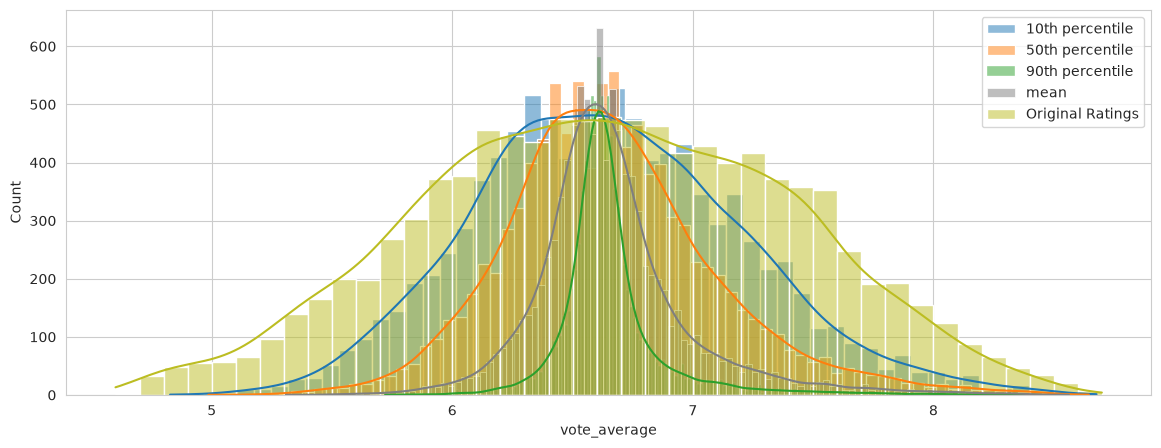

In [17]:
m_grid = [0.1, 0.5, 0.9, 1.01] # note: 1.01 will denote the mean count
m_names = ["10th percentile", "50th percentile", "90th percentile", "mean"] 
m_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f", "#bcbd22"]

sns.set_style("whitegrid")
plt.figure(figsize=(14, 5)) 

for i,m in enumerate(m_grid):
    if m == 1.01:
        m_value = df['vote_count'].mean()
    else:
        m_value = df['vote_count'].quantile(m)

    weighted_ratings_m = df.apply(calc_weighted_rating, axis=1, m=m_value)

    sns.histplot(weighted_ratings_m, color=m_colors[i], label=m_names[i], kde=True)

sns.histplot(df['vote_average'], color=m_colors[-1], label="Original Ratings", kde=True)

plt.legend()
plt.show()


So, while using the 10th percentile tends to produce a distribution pretty similar to the original ratings, using the 90th percentile or even average count seems to overpenalize several movies with smaller counts, pushing them heavily towards the grand mean. Using the 50th percentile seems to produce a good tradeoff, allowing movies still to be discovered while balancing the penalty towards low-count ratings. 

**Note**: for the sake of simplicity, this was carried out as a preliminary offline analysis, before ingestion into the database. In a production setting, the choice of $M$ would be folded into the retrieval evaluation system and scored against relevance judgments, like the text-search weights. Since building golden "best rated" lists is subjective and out of scope for this project, I instead selected $M$ by simply comparing rating distributions and resorting to heuristics.

In [18]:
VOTE_FLOOR_M = np.median(df.vote_count) # median vote count across all movies

In [19]:
df_clean = df.assign(
    title=df.title.str.strip(),
    language=df.original_language.str.strip(),
    year=df.release_date.str.split('-').str[0].astype(int), 
    genres=df.genre.str.split('|').apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else []),
    plot=df.overview.str.strip(),
    vote_count=df.vote_count.apply(lambda x: int(float(x))), 
    rating=df.vote_average.apply(lambda x: float(x) if pd.notnull(x) else None), 
    weighted_rating=df.apply(calc_weighted_rating, axis=1, m=VOTE_FLOOR_M)
)[[
    'id', 'title', 'year', 'genres', 'language', 'rating', 'plot', 'rating', 'vote_count', 'weighted_rating', 'plot'
]]

df_clean.head()

,id,title,year,genres,language,rating,plot,rating,vote_count,weighted_rating,plot
0,278,The Shawshank Redemption,1994,"[Drama,Crime]",en,8.7,Framed in the 1940s for the double murder of h...,8.7,21862,8.646,Framed in the 1940s for the double murder of h...
1,19404,Dilwale Dulhania Le Jayenge,1995,"[Comedy,Drama,Romance]",hi,8.7,"Raj is a rich, carefree, happy-go-lucky second...",8.7,3731,8.418,"Raj is a rich, carefree, happy-go-lucky second..."
2,238,The Godfather,1972,"[Drama,Crime]",en,8.7,"Spanning the years 1945 to 1955, a chronicle o...",8.7,16280,8.628,"Spanning the years 1945 to 1955, a chronicle o..."
3,424,Schindler's List,1993,"[Drama,History,War]",en,8.6,The true story of how businessman Oskar Schind...,8.6,12959,8.515,The true story of how businessman Oskar Schind...
4,240,The Godfather: Part II,1974,"[Drama,Crime]",en,8.6,In the continuing saga of the Corleone crime f...,8.6,9811,8.489,In the continuing saga of the Corleone crime f...


### Data Storage 

In [ ]:
df_clean.to_csv(
    "./data/top10K-TMDB-movies.csv",
    index=False
)